# Lego Sets

LEGO sets released from 1970 to 2022, including details on each set's theme, pieces, recommended age, retail price, and image.

**Recommended Analysis**
1. How many LEGO sets have been released since 1970? Is there a noticable trend?
2. Is there a relationship between the price of a set and its number of pieces?
3. Which has been the most popular theme in each decade?
4. Are LEGO minifigures most closely tied to licensed sets?

Import Packages and Dataset, as well as Instantiate Constant Variables

In [54]:
# Import Packages --------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid")

# Instantiate Constant Variables --------------
dataset_filename = "lego_sets.csv";
dataset_dictionary_filename = 'lego_sets_data_dictionary.csv';

# Import Dataset ---------------------
df = pd.read_csv(dataset_filename);
df_dict = pd.read_csv(dataset_dictionary_filename);


In [55]:
print(df_dict.info());
df_dict.head()

<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Field        14 non-null     str  
 1   Description  14 non-null     str  
dtypes: str(2)
memory usage: 356.0 bytes
None


,Field,Description
0,set_id,Official LEGO item number
1,name,Name of the LEGO set
2,year,Release year
3,theme,LEGO theme the set belongs to
4,subtheme,Subtheme within the theme


In [56]:
print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 18457 entries, 0 to 18456
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   set_id          18457 non-null  str    
 1   name            18457 non-null  str    
 2   year            18457 non-null  int64  
 3   theme           18457 non-null  str    
 4   subtheme        14901 non-null  str    
 5   themeGroup      18455 non-null  str    
 6   category        18457 non-null  str    
 7   pieces          14533 non-null  float64
 8   minifigs        8399 non-null   float64
 9   agerange_min    6787 non-null   float64
 10  US_retailPrice  6982 non-null   float64
 11  bricksetURL     18457 non-null  str    
 12  thumbnailURL    17451 non-null  str    
 13  imageURL        17451 non-null  str    
dtypes: float64(4), int64(1), str(9)
memory usage: 2.0 MB
None


,set_id,name,year,theme,subtheme,themeGroup,category,pieces,minifigs,agerange_min,US_retailPrice,bricksetURL,thumbnailURL,imageURL
0,1-8,Small house set,1970,Minitalia,NaN,Vintage,Normal,67.0,NaN,NaN,NaN,https://brickset.com/sets/1-8,https://images.brickset.com/sets/small/1-8.jpg,https://images.brickset.com/sets/images/1-8.jpg
1,2-8,Medium house set,1970,Minitalia,NaN,Vintage,Normal,109.0,NaN,NaN,NaN,https://brickset.com/sets/2-8,https://images.brickset.com/sets/small/2-8.jpg,https://images.brickset.com/sets/images/2-8.jpg
2,3-6,Medium house set,1970,Minitalia,NaN,Vintage,Normal,158.0,NaN,NaN,NaN,https://brickset.com/sets/3-6,https://images.brickset.com/sets/small/3-6.jpg,https://images.brickset.com/sets/images/3-6.jpg
3,4-4,Large house set,1970,Minitalia,NaN,Vintage,Normal,233.0,NaN,NaN,NaN,https://brickset.com/sets/4-4,https://images.brickset.com/sets/small/4-4.jpg,https://images.brickset.com/sets/images/4-4.jpg
4,4-6,Mini House and Vehicles,1970,Samsonite,Model Maker,Vintage,Normal,NaN,NaN,NaN,NaN,https://brickset.com/sets/4-6,NaN,NaN


**1. How many LEGO sets have been released since 1970? Is there a noticable trend?**

Total LEGO sets released since 1970: 18457


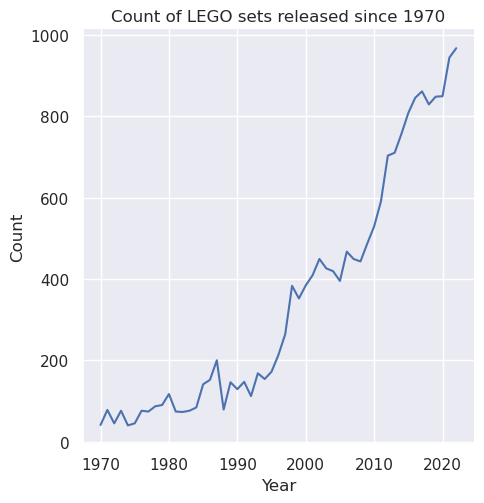

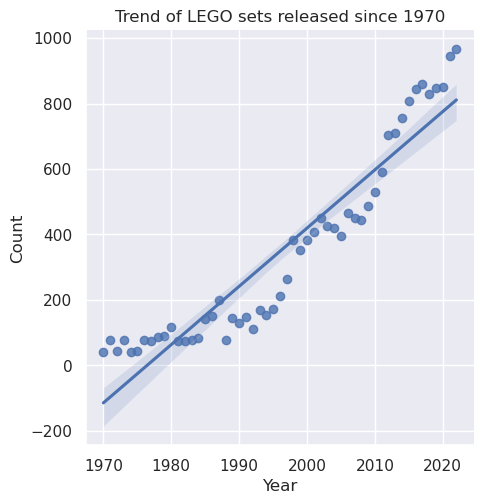

In [57]:
def setsSinceYear(data, year):
    dff = data.copy();
    dff = dff[dff['year'] >= year];
    dff_agg = dff['year'].value_counts().sort_values();
    print("Total LEGO sets released since " + str(year) + ": " + str(np.sum(dff_agg)));
    dataframe = pd.DataFrame({
        'Year': dff_agg.index.tolist(),
        'Count': dff_agg.values.tolist()
    });
    sns.relplot(data=dataframe, x="Year", y="Count", kind="line").set(title=f"Count of LEGO sets released since {str(year)}");
    sns.lmplot(data=dataframe, x="Year", y="Count").set(title=f"Trend of LEGO sets released since {str(year)}");

setsSinceYear(df, 1970)

**2. Is there a relationship between the price of a set and its number of pieces?**

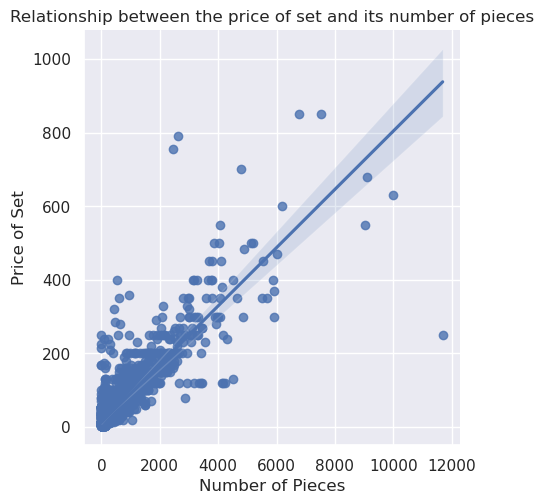

In [58]:
def relationPricePieces(data):
    dff = data.copy();
    dff_filtered = dff[dff['pieces'].notnull() & dff['US_retailPrice'].notnull()];
    dataframe = pd.DataFrame({
        'Price of Set': dff_filtered['US_retailPrice'],
        'Number of Pieces': dff_filtered['pieces'],
    });
    sns.lmplot(data=dataframe, x="Number of Pieces", y="Price of Set").set(title="Relationship between the price of set and its number of pieces");

relationPricePieces(df)

**3. Which has been the most popular theme in each decade?**

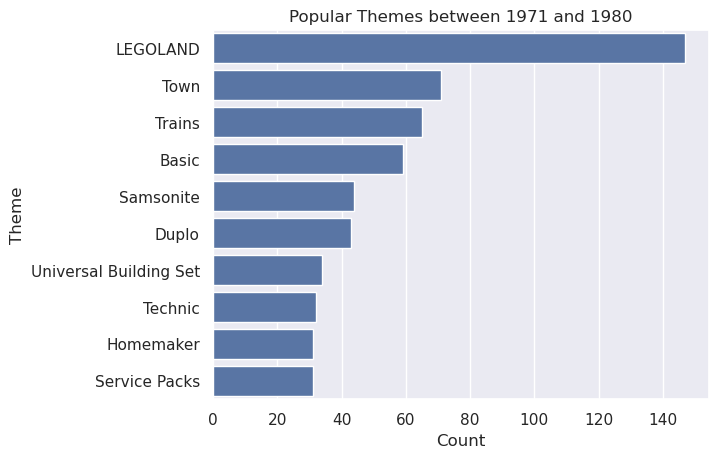

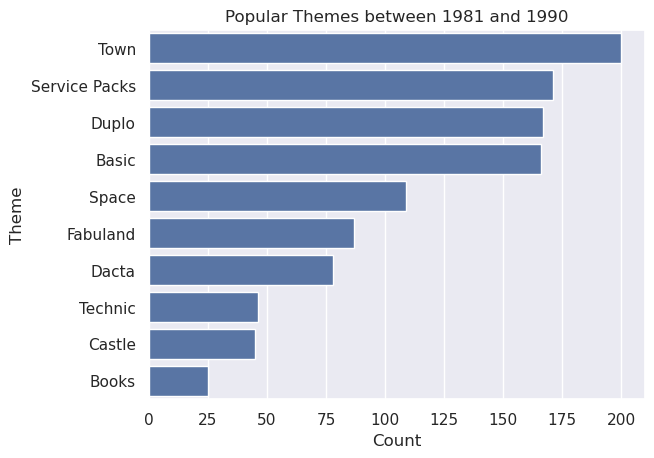

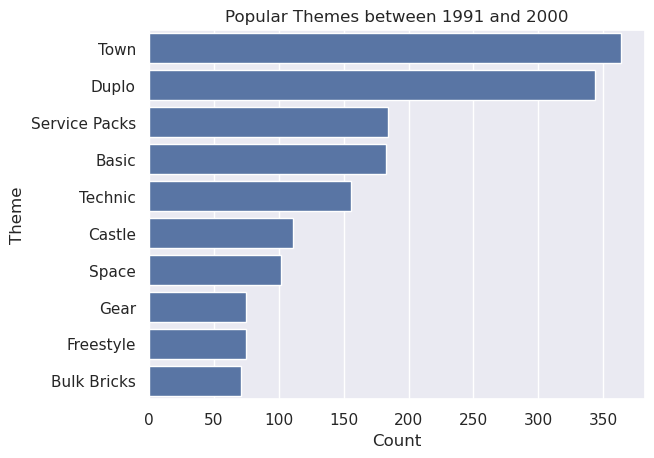

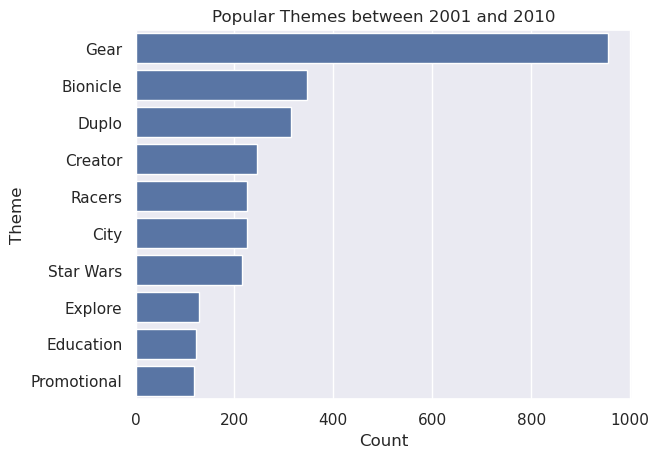

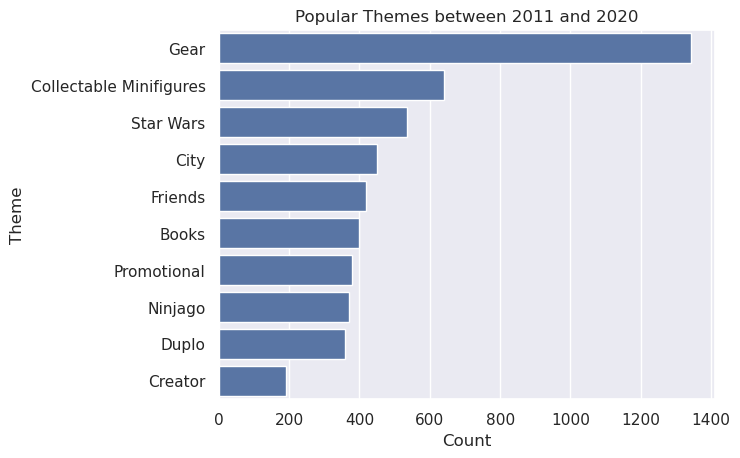

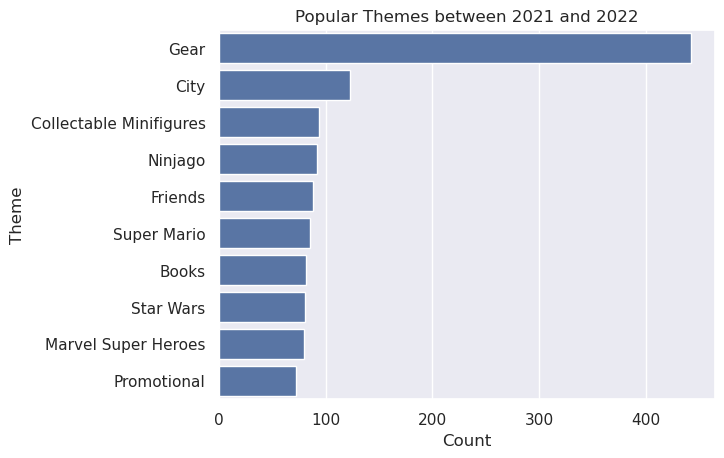

In [59]:
def popularThemeDecade(data, year, limit):
    dff = data.copy();
    dff = dff[dff['year'].between(year+1, year+10)];
    dff_agg = dff['theme'].value_counts().sort_values(ascending=False);
    yearLimit = dff['year'].max();
    dataframe = pd.DataFrame({
        'Theme': dff_agg.index.tolist(),
        'Count': dff_agg.values.tolist()
    });
    plt.figure()
    sns.barplot(data=dataframe[0:limit], x="Count", y="Theme").set(title=f"Popular Themes between {str(year+1)} and {str(yearLimit)}");
    plt.show();

def popularThemesEachDecade(data, limit):
    years = data['year'].unique();
    decadeYears = years[0:len(years):10];
    for year in decadeYears:
        popularThemeDecade(data, year, limit);

popularThemesEachDecade(df, 10)

**4. Are LEGO minifigures most closely tied to licensed sets?**

In [61]:
df['themeGroup'].unique().tolist()

['Vintage',
 'Modern day',
 'Miscellaneous',
 'Pre-school',
 'Basic',
 'Educational',
 'Technical',
 'Historical',
 'Action/Adventure',
 'Junior',
 'Girls',
 'Model making',
 'Racing',
 'Licensed',
 'Constraction',
 nan,
 'Art and crafts']